# 17 · 교량 바닥판 설계 — KDS 24 한계상태설계법

PSC 거더교의 콘크리트 바닥판을 **내측부**와 **캔틸레버부**로 나누어
설계한다. 거더는 KL-510 트럭을 다리 위로 굴려 풀지만, 바닥판은 기준이
주는 근사식으로 끝난다.

```
① 교량 제원과 재하차로   KDS 24 12 21 4.3.1.1
② 두께와 피복            KDS 24 14 21 4.6.5.1, 4.4.4
③ 내측부 하중            KDS 24 10 11 4.6.2.4, 4.6.2.7
④ 하중조합               KDS 24 12 11 표 4.1-1
⑤ 내측부 휨 설계         KDS 24 14 21 4.1.1
⑥ 캔틸레버부             KDS 24 10 11 4.6.2.5
⑦ 배력철근               KDS 24 14 21 4.6.5.3(2)
⑧ 사용성                 KDS 24 14 21 4.2
⑨ KDS 14 대조
```

원리를 그림으로 따라가려면
[강의 L4](../lectures/L4_바닥판설계.ipynb) 를, 값을 슬라이더로 바꿔
보려면 [대화형 탐색기](../_static/explorer.html)의 L4 탭을 연다.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

# 한글 글꼴이 없는 환경에서도 그림이 깨지지 않도록 축 라벨은 ASCII 로 둔다
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 96

In [2]:
import math

from concreteproperties_kds.kds import stress_block_parameters
from concreteproperties_kds.kds24 import (
    COMBINATIONS_BY_NAME, MIN_THICKNESS_RC, WHEEL_LOAD,
    bar_area, cantilever_live_load_moment, cantilever_wheel_width,
    dead_load_moment, deck_deflection_limit, deck_span,
    design_compressive_strength, design_yield_strength,
    distribution_steel_ratio, equivalent_block, impact_factor,
    lane_width, live_load_moment, max_bar_diameter, max_bar_spacing,
    minimum_flexural_steel, nominal_cover, number_of_lanes,
    provided_steel_area, required_steel_area,
)

# 교량 제원
TOTAL_WIDTH, ROADWAY_WIDTH, PLAN_LANE = 12.6, 11.2, 3.5
N_GIRDER, GIRDER_SPACING, CANTILEVER = 5, 2.5, 1.3
FCK, FY, EXPOSURE, PAVEMENT = 27.0, 400.0, "ED1", 80.0
GAMMA_C, GAMMA_P = 24.5, 22.5
BARRIER_LOAD, BARRIER_ARM = 8.0, 0.25
THICKNESS, HAUNCH = 240.0, 280.0

print(f"거더 {N_GIRDER} 본 @ {GIRDER_SPACING} m + 캔틸레버 {CANTILEVER} m × 2"
      f" = {(N_GIRDER - 1) * GIRDER_SPACING + 2 * CANTILEVER:.1f} m")

거더 5 본 @ 2.5 m + 캔틸레버 1.3 m × 2 = 12.6 m


## ① 교량 제원과 재하차로

재하차로는 **거더** 설계에 쓴다. 바닥판 근사식(4.6.2.4)에는 다차로
재하계수를 곱하지 않는다 — 식 자체가 인접 윤하중의 겹침을 이미 담고
있기 때문이다.

In [3]:
n_lane = number_of_lanes(roadway_width=ROADWAY_WIDTH, plan_lane_width=PLAN_LANE)
w_lane = lane_width(roadway_width=ROADWAY_WIDTH, n_lanes=n_lane)

print(f"교폭 W_C        {ROADWAY_WIDTH:.1f} m")
print(f"재하차로 수 N   {n_lane}       (식 (4.3-1))")
print(f"재하차로 폭 W   {w_lane:.2f} m   (식 (4.3-2))")
print(f"윤하중 P        {WHEEL_LOAD:.0f} kN    (KL-510 의 192 kN 축의 절반)")

교폭 W_C        11.2 m
재하차로 수 N   3       (식 (4.3-1))
재하차로 폭 W   3.60 m   (식 (4.3-2))
윤하중 P        96 kN    (KL-510 의 192 kN 축의 절반)


## ② 두께와 피복두께

제설염을 맞는 고속도로 바닥판이므로 노출등급을 **ED1** 로 잡는다.
피복이 55 mm 로 두꺼워져 유효깊이를 그만큼 잃는다.

In [4]:
span = deck_span(girder_spacing=GIRDER_SPACING, thickness=THICKNESS)
dia_in, spacing_in = 16.0, 150.0
t_min, cover = nominal_cover(exposure=EXPOSURE, bar_diameter=dia_in)
d_in = THICKNESS - cover - dia_in / 2

print(f"바닥판 지간 L    {span:.2f} m      (4.6.2.3(1))")
print(f"두께 t           {THICKNESS:.0f} mm     (최소 {MIN_THICKNESS_RC:.0f} mm)")
print(f"두께 / 지간      1 / {span * 1000 / THICKNESS:.1f}")
print(f"최소피복         {t_min:.0f} mm      (표 4.4-4, {EXPOSURE})")
print(f"공칭피복         {cover:.0f} mm      (+ 설계 편차 10 mm)")
print(f"유효깊이 d       {d_in:.0f} mm")

바닥판 지간 L    2.50 m      (4.6.2.3(1))
두께 t           240 mm     (최소 220 mm)
두께 / 지간      1 / 10.4
최소피복         45 mm      (표 4.4-4, ED1)
공칭피복         55 mm      (+ 설계 편차 10 mm)
유효깊이 d       177 mm


## ③ 내측부 하중과 ④ 하중조합

In [5]:
w_dc = GAMMA_C * THICKNESS / 1000.0
w_dw = GAMMA_P * PAVEMENT / 1000.0
m_dc = dead_load_moment(w=w_dc, span=span, kind="연속판_지간")
m_dw = dead_load_moment(w=w_dw, span=span, kind="연속판_지간")
m_ll = live_load_moment(span=span, continuous=True)
m_im = m_ll * (impact_factor() - 1.0)

loads = {"DC": m_dc, "DW": m_dw, "LL": m_ll, "IM": m_im}
m_ed = COMBINATIONS_BY_NAME["극한Ⅰ"].evaluate(loads=loads)
m_ser = COMBINATIONS_BY_NAME["사용Ⅰ"].evaluate(loads=loads)
total = m_dc + m_dw + m_ll + m_im

print(f"자중 DC     {w_dc:5.2f} kN/m²  ->  M = wL²/10 = {m_dc:5.2f} kN·m/m")
print(f"포장 DW     {w_dw:5.2f} kN/m²  ->  M = wL²/10 = {m_dw:5.2f} kN·m/m")
print(f"활하중 LL   (L+0.6)P/9.6 × 0.8    = {m_ll:5.2f} kN·m/m")
print(f"충격 IM     × 1.25                = {m_im:5.2f} kN·m/m")
print(f"                          계수 전 합 {total:5.2f}, "
      f"활하중의 몫 {(m_ll + m_im) / total * 100:.0f} %")
print()
print(f"극한Ⅰ  1.25 DC + 1.50 DW + 1.80 (LL+IM) = {m_ed:6.2f} kN·m/m")
print(f"사용Ⅰ  1.00 DC + 1.00 DW + 1.00 (LL+IM) = {m_ser:6.2f} kN·m/m")

자중 DC      5.88 kN/m²  ->  M = wL²/10 =  3.67 kN·m/m
포장 DW      1.80 kN/m²  ->  M = wL²/10 =  1.12 kN·m/m
활하중 LL   (L+0.6)P/9.6 × 0.8    = 24.80 kN·m/m
충격 IM     × 1.25                =  6.20 kN·m/m
                          계수 전 합 35.80, 활하중의 몫 87 %

극한Ⅰ  1.25 DC + 1.50 DW + 1.80 (LL+IM) =  62.08 kN·m/m
사용Ⅰ  1.00 DC + 1.00 DW + 1.00 (LL+IM) =  35.80 kN·m/m


## ⑤ 내측부 휨 설계

KDS 24 이므로 재료계수가 재료에 이미 들어 있다. 해석 결과가 곧 설계강도다.

In [6]:
def capacity(a_s, d):
    """배치 철근량으로 설계휨강도를 구한다 (kN·m/m)."""
    f_cd = design_compressive_strength(fck=FCK)
    f_yd = design_yield_strength(fy=FY)
    alpha, beta = equivalent_block(fck=FCK)
    c = a_s * f_yd / (alpha * f_cd * 1000.0)
    return a_s * f_yd * (d - beta * c) / 1e6


def steel_stress(m_service, a_s, d, n_ratio=7.0):
    """균열단면의 철근 인장응력 (MPa)."""
    rho = a_s / (1000.0 * d)
    k = math.sqrt((n_ratio * rho) ** 2 + 2 * n_ratio * rho) - n_ratio * rho
    return m_service * 1e6 / (a_s * (1.0 - k / 3.0) * d)


as_req = required_steel_area(m_ed=m_ed * 1e6, d=d_in)
as_min = minimum_flexural_steel(d=d_in)
as_prov = provided_steel_area(diameter=dia_in, spacing=spacing_in)
m_rd = capacity(as_prov, d_in)

print(f"f_cd = {design_compressive_strength(fck=FCK):.2f} MPa, "
      f"f_yd = {design_yield_strength(fy=FY):.1f} MPa")
print(f"필요 As    {as_req:6.0f} mm²/m")
print(f"최소 As    {as_min:6.0f} mm²/m")
print(f"배치 D16@150 {as_prov:5.0f} mm²/m")
print(f"M_Rd       {m_rd:6.2f} kN·m/m   ->  M_Rd/M_Ed = {m_rd / m_ed:.2f}")

f_cd = 14.92 MPa, f_yd = 360.0 MPa
필요 As      1052 mm²/m
최소 As       619 mm²/m
배치 D16@150  1340 mm²/m
M_Rd        77.36 kN·m/m   ->  M_Rd/M_Ed = 1.25


## ⑥ 캔틸레버부

내민 바닥판에는 **방호벽 자중**이 긴 지렛대 팔로 걸린다. 윤하중은 차도
끝에서 300 mm 안쪽에 놓는다(4.6.2.3(3)⑤).

In [7]:
x_wheel = CANTILEVER - 0.3
e_width = cantilever_wheel_width(x=x_wheel)
dia_c, spacing_c = 19.0, 125.0
_, cover_c = nominal_cover(exposure=EXPOSURE, bar_diameter=dia_c)
d_c = HAUNCH - cover_c - dia_c / 2

w_dc_c = GAMMA_C * HAUNCH / 1000.0
m_dc_c = abs(dead_load_moment(w=w_dc_c, span=CANTILEVER, kind="캔틸레버판"))
m_dc_c += BARRIER_LOAD * (CANTILEVER - BARRIER_ARM)
m_dw_c = abs(dead_load_moment(w=w_dw, span=CANTILEVER - 0.5, kind="캔틸레버판"))
m_ll_c = cantilever_live_load_moment(x=x_wheel)
m_im_c = m_ll_c * (impact_factor() - 1.0)

loads_c = {"DC": m_dc_c, "DW": m_dw_c, "LL": m_ll_c, "IM": m_im_c}
m_ed_c = COMBINATIONS_BY_NAME["극한Ⅰ"].evaluate(loads=loads_c)
m_ser_c = COMBINATIONS_BY_NAME["사용Ⅰ"].evaluate(loads=loads_c)
as_prov_c = provided_steel_area(diameter=dia_c, spacing=spacing_c)
m_rd_c = capacity(as_prov_c, d_c)

print(f"윤하중 위치 X   {x_wheel:.2f} m")
print(f"분포폭 E        {e_width:.2f} m   (식 (4.6-4))")
print(f"고정단 두께     {HAUNCH:.0f} mm (헌치),  d = {d_c:.0f} mm")
print()
print(f"자중 + 방호벽   {m_dc_c:6.2f} kN·m/m")
print(f"포장            {m_dw_c:6.2f} kN·m/m")
print(f"활하중 + 충격   {m_ll_c + m_im_c:6.2f} kN·m/m")
print(f"극한Ⅰ M_Ed    {m_ed_c:6.2f} kN·m/m   "
      f"(내측부의 {m_ed_c / m_ed:.1f} 배)")
print()
print(f"배치 D19@125 (상부) {as_prov_c:5.0f} mm²/m")
print(f"M_Rd            {m_rd_c:6.2f} kN·m/m   ->  M_Rd/M_Ed = {m_rd_c / m_ed_c:.2f}")

윤하중 위치 X   1.00 m
분포폭 E        1.94 m   (식 (4.6-4))
고정단 두께     280 mm (헌치),  d = 216 mm

자중 + 방호벽    14.20 kN·m/m
포장              0.58 kN·m/m
활하중 + 충격    61.86 kN·m/m
극한Ⅰ M_Ed    129.95 kN·m/m   (내측부의 2.1 배)

배치 D19@125 (상부)  2268 mm²/m
M_Rd            152.90 kN·m/m   ->  M_Rd/M_Ed = 1.18


**아래 코드가 하는 일** — 두 단면의 하중 구성과 강도를 나란히 그린다.
캔틸레버가 왜 지배하는지 한눈에 보인다.

M_Ed 증가분 67.9 kN·m/m 중 활하중이 82 % 를 차지한다.
고정하중의 몫은 13 % 에서 19 % 로 늘 뿐이다.


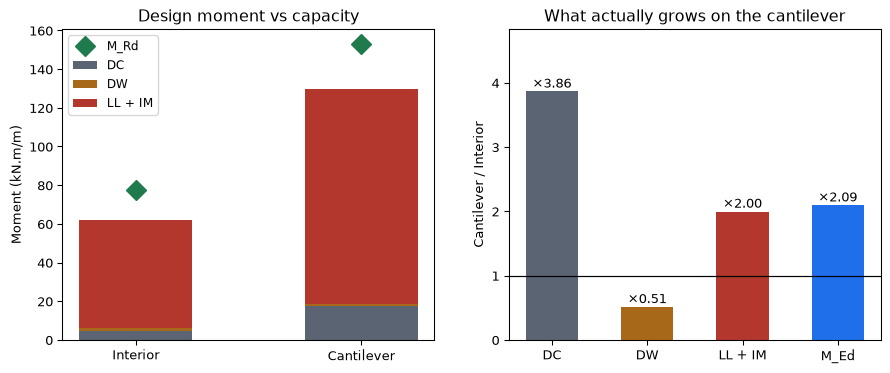

In [8]:
fig, (ax, bx) = plt.subplots(1, 2, figsize=(11, 4.2))

labels = ["Interior", "Cantilever"]
parts = [
    ("DC", [1.25 * m_dc, 1.25 * m_dc_c], "#5b6472"),
    ("DW", [1.50 * m_dw, 1.50 * m_dw_c], "#a8681a"),
    ("LL + IM", [1.80 * (m_ll + m_im), 1.80 * (m_ll_c + m_im_c)], "#b3372c"),
]
bottom = np.zeros(2)
for name, vals, col in parts:
    ax.bar(labels, vals, 0.5, bottom=bottom, label=name, color=col)
    bottom += np.array(vals)
ax.plot(labels, [m_rd, m_rd_c], "D", color="#1f7a4d", ms=11, label="M_Rd")
ax.set_ylabel("Moment (kN.m/m)")
ax.set_title("Design moment vs capacity")
ax.legend(fontsize=9)

names = ["DC", "DW", "LL + IM", "M_Ed"]
ratios = [m_dc_c / m_dc, m_dw_c / m_dw,
          (m_ll_c + m_im_c) / (m_ll + m_im), m_ed_c / m_ed]
cols = ["#5b6472", "#a8681a", "#b3372c", "#1f6feb"]
bx.bar(names, ratios, 0.55, color=cols)
bx.axhline(1.0, color="k", lw=0.9)
bx.set_ylabel("Cantilever / Interior")
bx.set_title("What actually grows on the cantilever")
for i, v in enumerate(ratios):
    bx.text(i, v + 0.06, f"×{v:.2f}", ha="center", fontsize=10)
bx.set_ylim(0, max(ratios) * 1.25)

grow_ll = 1.80 * ((m_ll_c + m_im_c) - (m_ll + m_im)) / (m_ed_c - m_ed) * 100
print(f"M_Ed 증가분 {m_ed_c - m_ed:.1f} kN·m/m 중 활하중이 {grow_ll:.0f} % 를 차지한다.")
print(f"고정하중의 몫은 {(m_dc + m_dw) / total * 100:.0f} % 에서 "
      f"{(m_dc_c + m_dw_c) / (m_dc_c + m_dw_c + m_ll_c + m_im_c) * 100:.0f} % 로 늘 뿐이다.")
plt.show()

방호벽 자중 때문에 캔틸레버가 지배한다고 생각하기 쉽지만, 숫자는 다르게
말한다. 고정하중 몫은 13 % 에서 19 % 로 늘 뿐이고, **M_Ed 증가분의
82 % 는 활하중**이다.

활하중이 정확히 2배가 되는 이유는 둘이다.

- 내측부는 연속판이라 정모멘트에 **0.8배**를 받지만, 캔틸레버는 그
  혜택이 없다.
- 캔틸레버의 윤하중은 폭 $E = 1.94$ m 에만 퍼진 채 1.0 m 지렛대 팔로
  걸린다.

방호벽이 기여하는 것은 M_Ed 증가분의 15 % 다. 적지 않지만 주범은
아니다.

## ⑦ 배력철근과 ⑧ 사용성

In [9]:
ratio = distribution_steel_ratio(span=span)
as_dist = ratio * as_prov

print(f"배력철근 비율   120/√L = {120 / math.sqrt(span):.1f} % -> 상한 {ratio * 100:.0f} %")
print(f"소요            {as_dist:.0f} mm²/m")
print(f"  D13 -> 간격 {bar_area(diameter=13.0) * 1000 / as_dist:.0f} mm 이하")
print()

for label, m_s, a_s, d_eff, dia, sp in (
    ("내측부", m_ser, as_prov, d_in, dia_in, spacing_in),
    ("캔틸레버", m_ser_c, as_prov_c, d_c, dia_c, spacing_c),
):
    f_s = steel_stress(m_s, a_s, d_eff)
    s_lim = max_bar_spacing(f_s=f_s)
    d_lim = max_bar_diameter(f_s=f_s)
    ok = "만족" if sp <= s_lim and dia <= d_lim else "불만족"
    print(f"{label:>8}  f_s {f_s:5.1f} MPa  허용간격 {s_lim:5.0f} (배치 {sp:.0f})  "
          f"허용지름 {d_lim:4.1f} (D{dia:.0f})  {ok}")

print()
print(f"처짐 한계   L/800 = {deck_deflection_limit(span=span * 1000):.1f} mm")
print("피로        검증 불필요 (4.6.5.1(3))")
print("전단        검토 생략 가능 (KDS 24 10 11 4.6.2.2(3))")

배력철근 비율   120/√L = 75.9 % -> 상한 67 %
소요            898 mm²/m
  D13 -> 간격 148 mm 이하

     내측부  f_s 166.2 MPa  허용간격   292 (배치 150)  허용지름 30.9 (D16)  만족
    캔틸레버  f_s 175.3 MPa  허용간격   281 (배치 125)  허용지름 29.3 (D19)  만족

처짐 한계   L/800 = 3.1 mm
피로        검증 불필요 (4.6.5.1(3))
전단        검토 생략 가능 (KDS 24 10 11 4.6.2.2(3))


## ⑨ KDS 14 로 풀면

하중은 어느 쪽이든 KDS 24 12 21 로 구한다 — 교량이니 KL-510 말고는 쓸
것이 없다. 갈리는 것은 단면 저항 쪽뿐이다.

In [10]:
def required_steel_kds14(m_u, d, phi=0.85):
    """같은 M_u 를 KDS 14 강도설계법으로 풀어 필요 철근량을 구한다."""
    _, eta, _ = stress_block_parameters(fck=FCK)
    k = FY / (eta * 0.85 * FCK * 1000.0)
    a2, a1 = phi * k * FY / 2.0, -phi * FY * d
    return (-a1 - math.sqrt(a1**2 - 4 * a2 * m_u)) / (2 * a2)


print(f"{'단면':>10}  {'M_Ed':>8}  {'KDS 24':>10}  {'KDS 14':>10}  {'차이':>7}")
for label, m, d_eff in (("내측부", m_ed, d_in), ("캔틸레버", m_ed_c, d_c)):
    a24 = required_steel_area(m_ed=m * 1e6, d=d_eff)
    a14 = required_steel_kds14(m * 1e6, d_eff)
    print(f"{label:>10}  {m:6.2f}  {a24:8.0f} mm²  {a14:8.0f} mm²  "
          f"{(a24 / a14 - 1) * 100:+6.1f} %")

        단면      M_Ed      KDS 24      KDS 14       차이
       내측부   62.08      1052 mm²      1090 mm²    -3.5 %
      캔틸레버  129.95      1879 mm²      1923 mm²    -2.3 %


## 설계 요약

| 항목 | 값 |
|---|---|
| 바닥판 두께 | 240 mm (내측) / 280 mm (캔틸레버 고정단, 헌치) |
| 주철근 | D16@150 (하부, 교축직각방향) |
| 캔틸레버 상부철근 | D19@125 |
| 배력철근 | D13@148 이하 |
| 공칭피복 | 55 mm (ED1, 제설염) |
| 콘크리트 | $f_{ck}$ 27 MPa (KDS 24 10 11 4.6.2.2(2)) |
| 철근 | SD400 이상 (4.6.5.2(5)①) |

**이 예제에서 얻을 것**

1. 바닥판은 트럭을 굴리지 않는다. 식 $(4.6\text{-}1)$ 한 줄이면 된다.
2. 캔틸레버의 설계휨모멘트가 내측부의 **2.1 배**다. 증가분의 82 % 는
   방호벽이 아니라 **활하중**이다 — 연속판의 0.8배 혜택이 없고, 윤하중이
   좁은 폭에 1.0 m 지렛대 팔로 걸리기 때문이다. 고정단 헌치는 그 결과다.
3. 노출등급 ED1 의 피복 55 mm 가 유효깊이를 63 mm 나 깎는다. 내구성의
   대가는 강도로 치른다.
4. 전단은 검토하지 않아도 되지만(4.6.2.2(3)), 이는 근사식이 이미 그
   범위에서 보정되었다는 전제 위에서다.

방호벽에 작용하는 **차량 충돌하중**(KDS 24 90 11, 극단상황한계상태)은
이 예제의 범위 밖이다. 실제 설계에서는 캔틸레버 상부철근이 충돌하중으로
결정되는 경우가 많다.